In [39]:
import sys
import os
sys.path.append('/project/GCRB/Hon_lab/s223695/Data_project/Perturb_seq_shared/')

import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.cluster import KMeans
import scipy.stats
from itertools import combinations
from sklearn.metrics import pairwise_distances

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize' : 'large',
                     'pdf.fonttype' : 42
                    }) 
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

import gc
import warnings
import time
import pickle
import json

from sklearn.metrics import pairwise_distances
from multiprocessing import Pool
import torch

from importlib import reload
import util_functions

In [2]:
!nvidia-smi

/bin/bash: nvidia-smi: コマンドが見つかりません


<h2>sgRNA filtering Version 3</h2>
1. Aggregate sgRNAs per genes<br>
2. Permute 1000times & use 10 random non-targeting background = Total 10000 permutation/ TF<br>
3. Calculate p-value by (total number of observed > shuffle for each background) / Total permutation<br>

In [3]:
torch.cuda.empty_cache

<function torch.cuda.memory.empty_cache() -> None>

In [4]:
!free -m

              total        used        free      shared  buff/cache   available
Mem:         515524       12074      502532          70         917      501556
Swap:         32767         313       32454


In [5]:
json_fp = "./config.json"
with open(json_fp, 'r') as fp:
    config = json.load(fp)
    input_file = config["input_data"]["input_file"]
    
sgRNA_file = config["input_data"]["sgRNA_file"]

gRNA_dict_file = config["user_defined_data"]["gRNA_dict_file"]
pca_file = config["user_defined_data"]["pca_file"]
annotation_file = config["user_defined_data"]["annotation_file"]


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

(X,gRNA_dict) = util_functions.load_files(input_file,sgRNA_file,gRNA_dict_file,pca_file)

read input
read pickle
read from dictionary


In [6]:
sgRNA_outlier_clear_df = pd.read_csv("Step1_sgRNA_outlier_pval_clear.csv",index_col=0)

In [7]:
sgRNA_outlier_clear_df.head()

,pval_outlier,target_region,target_name
chr9:130713809-130713827(+),0.9880,chr9:130713809-130714264,ABL1_ENST00000372348.2
chr9:130713821-130713839(+),0.9880,chr9:130713809-130714264,ABL1_ENST00000372348.2
chr9:130713859-130713877(+),0.9686,chr9:130713809-130714264,ABL1_ENST00000372348.2
chr9:130713979-130713997(-),0.9283,chr9:130713809-130714264,ABL1_ENST00000372348.2
chr9:130714246-130714264(-),0.9686,chr9:130713809-130714264,ABL1_ENST00000372348.2


In [8]:
clear_sgRNA_list = sgRNA_outlier_clear_df.index.tolist()

In [9]:
annotation_df = pd.read_csv(annotation_file,index_col=0)
annotation_df.head()

,guide_chr,guide_start,guide_end,score,strand,protospacer_target,intended_target_region,gene_target,source,closest_gene,closest_dist,closest_gene_target,closest_dist_target
0,chr9,130713821,130713839,.,+,chr9:130713821-130713839(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56
1,chr9,130713809,130713827,.,+,chr9:130713809-130713827(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56
2,chr9,130713859,130713877,.,+,chr9:130713859-130713877(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56
3,chr9,130714246,130714264,.,-,chr9:130714246-130714264(-),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56
4,chr9,130713865,130713883,.,+,chr9:130713865-130713883(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56


In [10]:
sgRNA_outlier_clear_df[sgRNA_outlier_clear_df["target_region"]=="chr10:101643893-101644393"].index.to_list()

['chr10:101643923-101643942(+)',
 'chr10:101643959-101643978(-)',
 'chr10:101644140-101644159(+)',
 'chr10:101644145-101644164(-)',
 'chr10:101644230-101644249(+)',
 'chr10:101644251-101644270(+)',
 'chr10:101644316-101644335(-)',
 'chr10:101644364-101644383(-)']

In [11]:
gRNA_region_dict = {}

OR_gRNA_list = [i for i in gRNA_dict.keys() if i.startswith("OR")]

for gRNA_tmp in OR_gRNA_list:
    gene_name = gRNA_tmp.split("-")[0]
    
    if gene_name in gRNA_region_dict.keys():
        gRNA_region_dict[gene_name] += [gRNA_tmp]
    else:
        gRNA_region_dict[gene_name] = [gRNA_tmp]

        
for target in np.unique(sgRNA_outlier_clear_df["target_region"]):
    gRNA_region_dict[target] = sgRNA_outlier_clear_df[sgRNA_outlier_clear_df["target_region"]==target].index.to_list()
    gRNA_region_dict[target] = np.unique(gRNA_region_dict[target])

In [12]:
cell_per_region_dict = {}
for key in gRNA_region_dict.keys():
    cell_list_tmp = np.concatenate([gRNA_dict[i] for i in gRNA_region_dict[key]])
    cell_per_region_dict[key] = np.unique(cell_list_tmp)


<h3>Select good non-target gRNA using K-means</h3>

In [13]:
non_target_gRNA_list = [item for item in list(gRNA_dict.keys()) 
                        if (item.startswith("non-targeting")) and 
                        (len(gRNA_dict[item])>20)]
cell_id_nontarget_list = [gRNA_dict[key] for key in non_target_gRNA_list]

In [14]:
res = util_functions.pairwise_torch(X,cell_id_nontarget_list,device,vardose=True)

100%|██████████| 1684/1684 [02:05<00:00, 13.45it/s]


In [15]:
torch.cuda.empty_cache()

In [16]:
len(cell_id_nontarget_list)

580

In [23]:
# make Dataframe from results
pairwise_list = np.zeros((len(non_target_gRNA_list),
                          len(non_target_gRNA_list)
                         ))
for p1, p2, val in tqdm(res):
    pairwise_list[p1,p2]=val
    pairwise_list[p2][p1]=val
df = pd.DataFrame(pairwise_list.copy(),
                  index=non_target_gRNA_list,
                  columns=non_target_gRNA_list) 

df.index.name = "sgRNA"
df.columns.name = "sgRNA"
df.name = 'pairwise PCA distances'

sigmas = np.diag(df)
deltas = df
target_estats = 2 * deltas - sigmas - sigmas[:, np.newaxis]
target_estats = target_estats.abs()

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(target_estats)
label,count = np.unique(kmeans.labels_,return_counts=True)
print(label,count)
#This is the non-target list for TF perturb seq
non_target_gRNA_name = target_estats.index.to_numpy()[kmeans.labels_ == label[np.argmax(count)]]

100%|██████████| 168490/168490 [00:00<00:00, 1420419.11it/s]


[0 1 2] [ 30 429 121]


In [71]:
non_target_gRNA_name_df = pd.Series(non_target_gRNA_name)
non_target_gRNA_name_df.to_csv("Step2_non_targeting_gRNA_clean.csv",index=None)
print(non_target_gRNA_name_df.shape)

(429,)


<h3>Calculate p-values with Permutation test</h3>

1. Aggregate per transcript<br>
2. Calculate Distance between non-target<br>
2. Mix and sample picking same number as test and control
3. Calculate e-distance between two samples
4. Repeat 1000times(100000times in the future)

In [25]:
print("Total:",len(gRNA_region_dict.keys()))

Total: 1431


In [21]:
reload(util_functions)
permute_per_bg = config["permutation_test"]["permute_per_bg"]
num_of_bg = config["permutation_test"]["num_of_bg"]
non_target_pick = config["permutation_test"]["non_target_pick"]
batch_num_basic = config["permutation_test"]["batch_num_basic"]

In [22]:
pval_dict = {}
non_target_cell_name = [gRNA_dict[i] for i in non_target_gRNA_name]

#concatenate all list together
non_target_cell_name = sum(non_target_cell_name,[])

#unique cell id list
non_target_cell_name = sorted(list(set(non_target_cell_name)))
pd.Series(non_target_cell_name).to_csv("Step2_non_targeting_cell_id_clean.csv")

In [23]:
#fix random cell with seed
np.random.seed(0)

non_target_cell_name_reduced = []

for i in range(num_of_bg):
    non_target_cell_name_reduced.append(np.random.choice(non_target_cell_name,non_target_pick))

In [24]:
pd.DataFrame(non_target_cell_name_reduced).to_csv("Step2_non_targeting_background.csv")

In [17]:
output_file = "Step2_pval_target.csv"

In [ ]:
pbar = tqdm(list(gRNA_region_dict.keys()))
for target_index, target_name in enumerate(pbar):
    target_cell_name = cell_per_region_dict[target_name]
    
    batch_num = batch_num_basic
    
    #conditioning based on cell number. If cell number is more than 10000, downsample to 10000
    if len(target_cell_name)>5000:
        flag=3
        batch_num=40
        target_cell_name = np.random.choice(target_cell_name,5000,replace=False)
        print(target_name,"is downsampled")
    elif len(target_cell_name)>2000:
        flag=2
        batch_num = 50
    elif len(target_cell_name)>1000:
        flag=1
        batch_num = 100
    else:
        flag=0
        batch_num = batch_num_basic
        
    for bg_index in range(num_of_bg):
            
        overlap = set(target_cell_name) & set(non_target_cell_name_reduced[bg_index])
        non_target_cell_name_clear = list(set(non_target_cell_name_reduced[bg_index])-overlap)
        target_cell_name_clear = list(set(target_cell_name)-overlap)
        try:
            pbar.set_postfix({"total cell num":len(target_cell_name),
                              "current iter":bg_index+1,
                              "mode":"GPU"
                             })
            (obs_edist,e_dist_list) = util_functions.permutation_test(X,target_cell_name_clear,
                                                                      non_target_cell_name_clear,
                                                                      device,batch_num,permute_per_bg)
        except Exception as e:
            gc.collect()
            torch.cuda.empty_cache()
            pbar.set_postfix({"total cell num":len(target_cell_name),
                              "current iter":bg_index+1,
                              "mode":"CPU"
                             })
            try:
                (obs_edist,e_dist_list) = util_functions.permutation_test(X,target_cell_name_clear,
                                                                          non_target_cell_name_clear,
                                                                          "cpu",batch_num,permute_per_bg)
            except Exception as es:
                print(es)

    
        if not target_name in pval_dict.keys():
            pval_dict[target_name] = {}
        pval_dict[target_name]["distance_"+str(bg_index)] = obs_edist.item()
        pval_dict[target_name]["pval_"+str(bg_index)] = (e_dist_list>obs_edist).sum().item()/permute_per_bg

    if target_index % 10 == 0:
        pd.DataFrame(pval_dict).T.to_csv(output_file)

pd.DataFrame(pval_dict).T.to_csv(output_file)

 19%|█▉        | 313/1637 [1:13:48<6:31:18, 17.73s/it, total cell num=5000, current iter=1, mode=GPU] 

chr6:21593726-21594227 is downsampled


 31%|███▏      | 515/1637 [2:13:26<6:50:23, 21.95s/it, total cell num=5000, current iter=1, mode=GPU]  

chr11:47408112-47408612 is downsampled


 33%|███▎      | 533/1637 [2:20:30<10:57:18, 35.72s/it, total cell num=2063, current iter=20, mode=GPU]

<h3>Stat of the result</h3>

In [18]:
result_df = pd.read_csv(output_file,index_col=0)

In [19]:
result_df.head()

,distance_0,pval_0,distance_1,pval_1,distance_2,pval_2,distance_3,pval_3,distance_4,pval_4,...,pval_19,pval_mean,pval_std,distance_mean,distance_std,pval_mean_log,distance_mean_log,region_name,source,is_enhancer
OR10G4,4.309937,0.019,4.863525,0.004,4.076660,0.015,2.286987,0.204,4.128052,0.017,...,0.058,0.03800,0.054145,4.246948,1.180880,1.420102,0.628077,OR10G4,Control,False
OR10H2,1.420410,0.652,1.601074,0.523,1.448120,0.654,1.128784,0.855,1.378418,0.686,...,0.816,0.66225,0.238118,1.441760,0.473596,0.178971,0.158893,OR10H2,Control,False
OR10H5,12.558105,0.000,13.742798,0.000,11.319946,0.000,9.702148,0.000,11.939331,0.000,...,0.000,0.00000,0.000000,12.162756,1.705439,5.000000,1.085032,OR10H5,Control,False
OR10K1,1.624512,0.634,1.484863,0.680,2.174927,0.339,1.305908,0.785,1.566772,0.678,...,0.705,0.58415,0.238986,1.753357,0.554499,0.233468,0.243870,OR10K1,Control,False
OR10P1,4.771973,0.014,4.610718,0.024,5.093262,0.011,3.394165,0.091,4.644043,0.018,...,0.014,0.03335,0.038007,4.666467,1.001044,1.476774,0.668988,OR10P1,Control,False


In [22]:
result_df["pval_mean"] = result_df.iloc[:,list(range(1,num_of_bg*2,2))].mean(axis=1)
result_df["pval_std"] = result_df.iloc[:,list(range(1,num_of_bg*2,2))].std(axis=1)

result_df["distance_mean"] = result_df.iloc[:,list(range(0,num_of_bg*2,2))].mean(axis=1)
result_df["distance_std"] = result_df.iloc[:,list(range(0,num_of_bg*2,2))].std(axis=1)

In [23]:
result_df["pval_mean_log"] = -np.log10(result_df["pval_mean"]+0.00001)
result_df["distance_mean_log"] = np.log10(result_df["distance_mean"])

In [24]:
annotation_df.head()

,guide_chr,guide_start,guide_end,score,strand,protospacer_target,intended_target_region,gene_target,source,closest_gene,closest_dist,closest_gene_target,closest_dist_target
0,chr9,130713821,130713839,.,+,chr9:130713821-130713839(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56
1,chr9,130713809,130713827,.,+,chr9:130713809-130713827(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56
2,chr9,130713859,130713877,.,+,chr9:130713859-130713877(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56
3,chr9,130714246,130714264,.,-,chr9:130714246-130714264(-),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56
4,chr9,130713865,130713883,.,+,chr9:130713865-130713883(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56


In [25]:
result_df["region_name"] = result_df.index.map(lambda x:
                                               annotation_df[annotation_df["intended_target_region"]==x]["gene_target"].values[0] \
                                               if not x.startswith("OR") else x)
result_df["source"] = result_df.index.map(lambda x:
                                          annotation_df[annotation_df["intended_target_region"]==x]["source"].values[0] \
                                          if not x.startswith("OR") else "Control"
                                         )
result_df["is_enhancer"] = result_df.region_name.apply(lambda x: x.startswith("Element"))

In [26]:
result_df

,distance_0,pval_0,distance_1,pval_1,distance_2,pval_2,distance_3,pval_3,distance_4,pval_4,...,pval_19,pval_mean,pval_std,distance_mean,distance_std,pval_mean_log,distance_mean_log,region_name,source,is_enhancer
OR10G4,4.309937,0.019,4.863525,0.004,4.076660,0.015,2.286987,0.204,4.128052,0.017,...,0.058,0.03800,0.054145,4.246948,1.180880,1.420102,0.628077,OR10G4,Control,False
OR10H2,1.420410,0.652,1.601074,0.523,1.448120,0.654,1.128784,0.855,1.378418,0.686,...,0.816,0.66225,0.238118,1.441760,0.473596,0.178971,0.158893,OR10H2,Control,False
OR10H5,12.558105,0.000,13.742798,0.000,11.319946,0.000,9.702148,0.000,11.939331,0.000,...,0.000,0.00000,0.000000,12.162756,1.705439,5.000000,1.085032,OR10H5,Control,False
OR10K1,1.624512,0.634,1.484863,0.680,2.174927,0.339,1.305908,0.785,1.566772,0.678,...,0.705,0.58415,0.238986,1.753357,0.554499,0.233468,0.243870,OR10K1,Control,False
OR10P1,4.771973,0.014,4.610718,0.024,5.093262,0.011,3.394165,0.091,4.644043,0.018,...,0.014,0.03335,0.038007,4.666467,1.001044,1.476774,0.668988,OR10P1,Control,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr9:32552225-32552725,1.833862,0.229,1.908813,0.178,1.620117,0.291,0.899292,0.831,1.659668,0.280,...,0.291,0.31220,0.214396,1.735931,0.472289,0.505553,0.239533,Element1264,TF,True
chr9:32572201-32573408,13.799805,0.000,15.709595,0.000,15.848022,0.000,10.903320,0.000,14.870117,0.000,...,0.000,0.00005,0.000224,14.890796,2.371317,4.221849,1.172918,Element1265,TF,True
chrX:73401649-73402149,2.317505,0.112,1.418091,0.413,2.382812,0.092,3.496582,0.009,1.948486,0.176,...,0.020,0.19035,0.159551,2.159351,0.614144,0.720424,0.334323,Element1266,TF,True
chrX:73511086-73511850,2.352173,0.455,3.304077,0.148,3.100464,0.188,2.979248,0.213,3.335205,0.171,...,0.344,0.23470,0.143728,3.116571,0.721683,0.629468,0.493677,Element1267,TF,True


In [27]:
result_df.to_csv(output_file)

<Axes: xlabel='distance_mean_log', ylabel='pval_mean_log'>

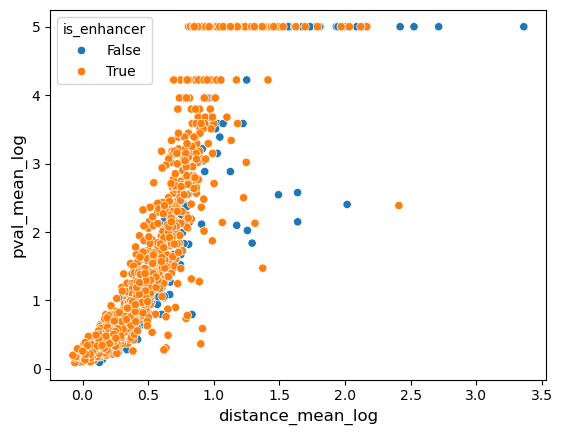

In [28]:
sns.scatterplot(data=result_df,x="distance_mean_log",y="pval_mean_log",hue="is_enhancer")
#sns.kdeplot(data=result_df,x="distance_mean_log",y="pval_mean_log",hue="is_enhancer")

<Axes: xlabel='pval_mean_log', ylabel='Count'>

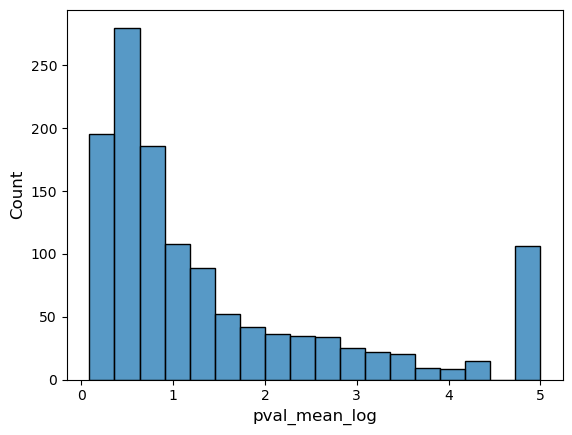

In [29]:
sns.histplot(data=result_df[result_df["is_enhancer"]],x="pval_mean_log")

<Axes: xlabel='pval_mean_log', ylabel='Count'>

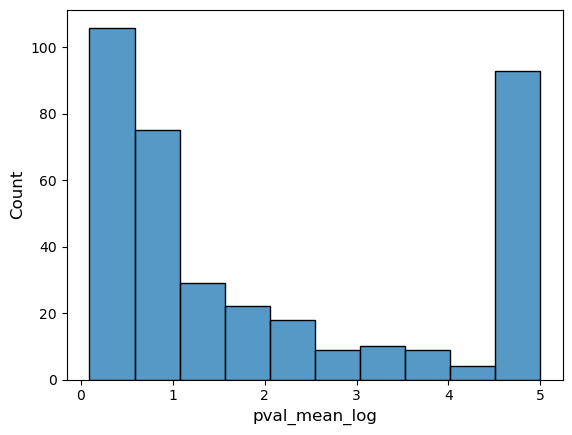

In [30]:
sns.histplot(data=result_df[~result_df["is_enhancer"]],x="pval_mean_log")

<Axes: xlabel='pval_mean_log', ylabel='Count'>

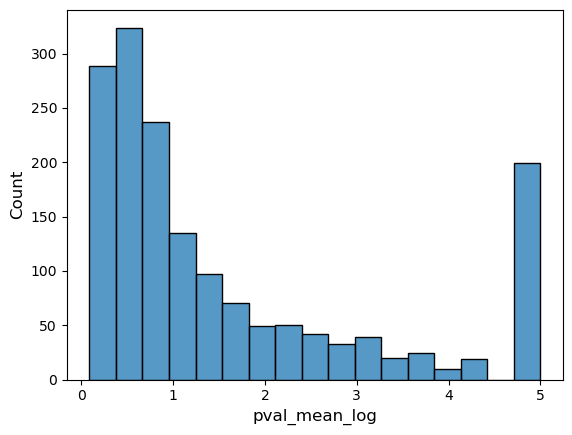

In [31]:
sns.histplot(result_df["pval_mean_log"])

<h3>Find cutoff</h3>

In [32]:
estat_transcript = result_df

p_val_cutoff_list = [1,0.1,0.05,0.01,0.005,0.001]
dist_cut_off_list = [0,5,10,12,15,20,30,50]
cut_off_df = pd.DataFrame(index=p_val_cutoff_list,columns=dist_cut_off_list)
cut_off_OR_df = pd.DataFrame(index=p_val_cutoff_list,columns=dist_cut_off_list)

for p_val_cutoff in p_val_cutoff_list:
    for dist_cut_off in dist_cut_off_list:
        estat_transcript_sig = estat_transcript[(estat_transcript["distance_mean"]>dist_cut_off) & 
                                               (estat_transcript["pval_mean"]<=p_val_cutoff )]
        transcript_sig_list = estat_transcript_sig.index.tolist()
        region_sig_list = np.unique(estat_transcript_sig["region_name"])
        
        is_OR = [x.startswith("OR") for x in region_sig_list]
        OR_num = sum(is_OR)
        
        cut_off_df.at[p_val_cutoff,dist_cut_off] = len(region_sig_list)
        cut_off_OR_df.at[p_val_cutoff,dist_cut_off] = OR_num

In [33]:
cut_off_df

,0,5,10,12,15,20,30,50
1.000,1637,429,196,163,129,91,46,23
0.100,760,423,196,163,129,91,46,23
0.050,623,420,196,163,129,91,46,23
0.010,455,395,194,161,127,90,46,23
0.005,403,369,189,157,124,88,45,23
0.001,311,302,182,151,119,84,41,21


In [34]:
cut_off_OR_df

,0,5,10,12,15,20,30,50
1.000,98,12,1,1,0,0,0,0
0.100,31,12,1,1,0,0,0,0
0.050,23,12,1,1,0,0,0,0
0.010,11,10,1,1,0,0,0,0
0.005,8,8,1,1,0,0,0,0
0.001,3,3,1,1,0,0,0,0


<h3>Filtering out low expression TFs</h3>

In [35]:
dist_cut_off = 0
p_val_cutoff = 0.001

estat_transcript_sig = estat_transcript[(estat_transcript["distance_mean"]>dist_cut_off) & 
                                       (estat_transcript["pval_mean"]<p_val_cutoff)]
transcript_sig_list = estat_transcript_sig.index.tolist()
region_sig_list = np.unique(estat_transcript_sig["region_name"])

In [36]:
result_df["Significant"] = ["Yes" if i in transcript_sig_list else "No" for i in result_df.index]

<Axes: xlabel='distance_mean_log', ylabel='pval_mean_log'>

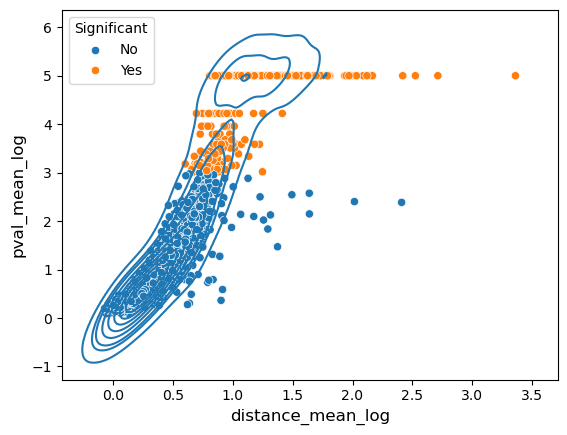

In [40]:
sns.scatterplot(data=result_df,x="distance_mean_log",y="pval_mean_log",
                hue="Significant",hue_order=["No","Yes"])
sns.kdeplot(data=result_df,x="distance_mean_log",y="pval_mean_log")

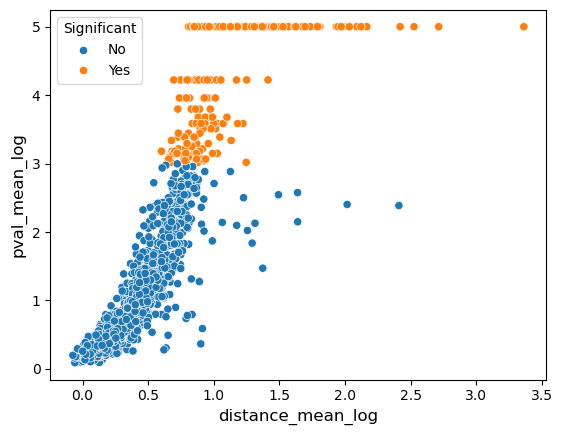

In [41]:
sns.scatterplot(data=result_df,x="distance_mean_log",y="pval_mean_log",
                hue="Significant",hue_order=["No","Yes"])
plt.savefig("./Step2_significant_stat.pdf")


In [49]:
print("Total sig",result_df[(result_df["Significant"]=="Yes")].shape[0])
print("Promoter",result_df[(result_df["is_enhancer"]==False) & (result_df["Significant"]=="Yes")].shape[0])
print("Enhancer",result_df[(result_df["is_enhancer"]==True) & (result_df["Significant"]=="Yes")].shape[0])

Total sig 310
Promoter 116
Enhancer 194


In [68]:
sgRNA_sig_list_tmp = [gRNA_region_dict[key] for key in estat_transcript_sig.index]
cell_sig_list_tmp = [cell_per_region_dict[key] for key in estat_transcript_sig.index]

estat_transcript_sig["num_sgRNA"] = [len(x) for x in sgRNA_sig_list_tmp]
estat_transcript_sig["num_cells"] = [len(x) for x in cell_sig_list_tmp]

/tmp/ipykernel_247832/1049642184.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estat_transcript_sig["num_sgRNA"] = [len(x) for x in sgRNA_sig_list_tmp]
/tmp/ipykernel_247832/1049642184.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  estat_transcript_sig["num_cells"] = [len(x) for x in cell_sig_list_tmp]


In [70]:
estat_transcript_sig.to_csv("Step2_pval_target_significant.csv")